# Financial Time Series
Financial analysis focuses on a number of different factors that can involve a company's strategic position alongside their results. Indexed time-series data is a great way to measure financial performance and success/failure of a given strategy. To start I'll set a date range, then build data sets that contain the names of the stocks we want to analyze.

In [1]:
from datetime import datetime
import pandas_datareader.data as wb
import pandas_datareader.iex as iex
import pandas as pd
import numpy as np

In [2]:
start_date = datetime(2018,1,1)
end_date = datetime(2022,4,7)

## Split & Build Data
I'm going to look at stocks in comparason to their segment of the economy. At the time of writing, consider that the New York Stock Exchange is trading ~1.46 billion shares per day across ~2,800 companies. This is not an all encompassing list, but is enough to conduct several financial studies and comparasons. Consider the following categories that I will break down.

### Indexes

In [3]:
index_instruments = ['SPDR S&P 500 ETF Trust', 'S&P 500 Index', 'VIX Volatility Index']
indexes = ['SPY', '^GSPC', '^VIX']

### Exchange Rates & Currency 

In [4]:
currency_instruments = ['EUR/USD Exchange Rate', 'Gold Price', 'VanEck Vectors Gold Miners ETF', 'SPDR Gold Trust']
currency = ['EURUSD=X', 'GDX', 'GLD']

### Investing & Banking

In [5]:
investment_instruments = ['Berkshire Hathaway', 'Goldman Sachs Stock', 'JP Morgan Chase & Co Stock', 'Morgan Stanley Stock', 'Bank of America Stock', 'Citigroup Stock', 'Creddit Suisse Stock']
invest_stocks = ['BRK-A', 'GS', 'JPM', 'MS', 'BAC', 'CS']

### Technology Companies

In [6]:
tech_instruments = ['Microsoft Stock', 'Apple Stock', 'Tesla Stock',
                    'Google Stock', 'Amazon Stock', 'Facebook Stock', 'Netflix Stock',
                    'Salesforce Stock', 'Service Now Stock', 'IBM Stock', 
                    'NVIDIA Stock', 'Intel Stock', 'Advanced Micro Devices Stock']
tech_stocks = ['MSFT', 'AAPL', 'TSLA', 'GOOG', 'AMZN', 'FB', 'NFLX', 'CRM', 'NOW', 'IBM', 'NVDA', 'INTC', 'AMD']

### Pharmaceutical Industry

In [7]:
pharm_instruments = ['Eli Lilly Stock', 'Johnson & Johnson Stock', 'Novartis Stock', 'Roche Stock']
pharm_stocks = ['LLY', 'JNJ', 'NVS', 'RHHBY']

### Healthcare Supply Chain

In [8]:
health_instruments = ['UnitedHealth Group', 'AmerisourceBergen Stock', 'McKesson Stock', 'Walmart Stock', 'CVS Stock']
health_stocks = ['UNH', 'ABC', 'MCK', 'WMT', 'CVS']

## Analysis of Close Data

In [9]:
tick_data = wb.DataReader(tech_stocks, 'yahoo', start_date, end_date)
eod = tick_data['Adj Close']
for ric, name in zip(eod.columns, tech_instruments):
    print('{:8s} | {}'.format(ric, name))

MSFT     | Microsoft Stock
AAPL     | Apple Stock
TSLA     | Tesla Stock
GOOG     | Google Stock
AMZN     | Amazon Stock
FB       | Facebook Stock
NFLX     | Netflix Stock
CRM      | Salesforce Stock
NOW      | Service Now Stock
IBM      | IBM Stock
NVDA     | NVIDIA Stock
INTC     | Intel Stock
AMD      | Advanced Micro Devices Stock


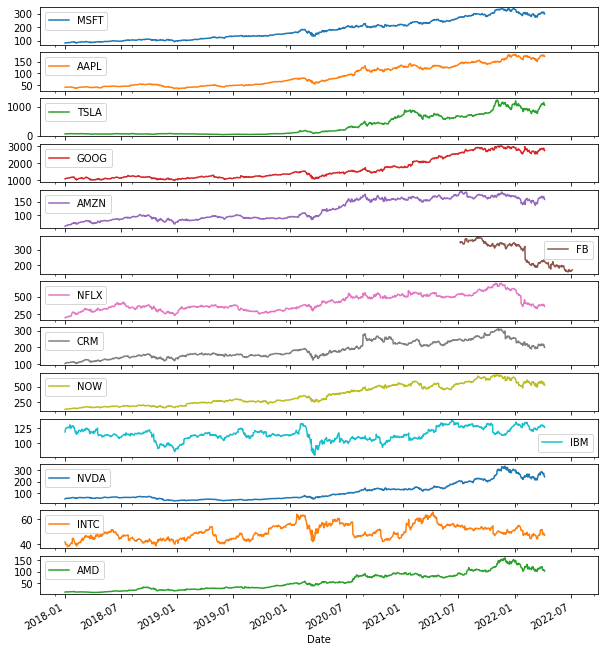

In [10]:
eod.plot(figsize=(10, 12), subplots=True);

## Summary Statistics

In [11]:
eod.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1135 entries, 2018-01-02 to 2022-07-06
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MSFT    1075 non-null   float64
 1   AAPL    1075 non-null   float64
 2   TSLA    1075 non-null   float64
 3   GOOG    1075 non-null   float64
 4   AMZN    1075 non-null   float64
 5   FB      252 non-null    float64
 6   NFLX    1075 non-null   float64
 7   CRM     1075 non-null   float64
 8   NOW     1075 non-null   float64
 9   IBM     1075 non-null   float64
 10  NVDA    1075 non-null   float64
 11  INTC    1075 non-null   float64
 12  AMD     1075 non-null   float64
dtypes: float64(13)
memory usage: 124.1 KB


In [12]:
eod.describe().round(2)

Symbols,MSFT,AAPL,TSLA,GOOG,AMZN,FB,NFLX,CRM,NOW,IBM,NVDA,INTC,AMD
count,1075.00,1075.00,1075.00,1075.00,1075.00,252.00,1075.00,1075.00,1075.00,1075.00,1075.00,1075.00,1075.00
mean,179.72,88.07,337.67,1645.51,120.54,282.50,413.42,185.87,366.20,115.14,108.26,49.52,57.57
std,76.24,44.57,345.52,641.79,37.73,73.31,108.60,49.55,166.60,10.17,75.58,5.72,38.38
min,80.45,34.41,35.79,976.22,59.45,155.85,201.07,104.03,131.73,80.85,31.55,37.88,9.53
25%,107.36,47.55,60.80,1148.39,88.06,207.24,329.32,147.74,202.87,109.25,52.23,44.77,25.07
50%,160.16,70.85,112.96,1347.30,99.72,323.67,375.22,164.20,299.61,114.34,66.95,48.63,48.21
75%,237.54,127.36,658.60,2094.04,160.24,342.15,504.68,227.68,522.03,122.08,140.63,53.91,85.63
max,341.61,181.51,1229.91,3014.18,186.57,382.18,691.69,309.96,701.73,137.75,333.59,65.91,161.91


In [13]:
eod.mean()

Symbols
MSFT     179.721126
AAPL      88.066020
TSLA     337.674397
GOOG    1645.512479
AMZN     120.544605
FB       282.502461
NFLX     413.417209
CRM      185.871153
NOW      366.202791
IBM      115.138079
NVDA     108.255495
INTC      49.515857
AMD       57.572995
dtype: float64

In [14]:
eod.aggregate([min,
              np.mean,
              np.std,
              np.median,
              max]
).round(2)

Symbols,MSFT,AAPL,TSLA,GOOG,AMZN,FB,NFLX,CRM,NOW,IBM,NVDA,INTC,AMD
min,80.45,34.41,35.79,976.22,59.45,155.85,201.07,104.03,131.73,80.85,31.55,37.88,9.53
mean,179.72,88.07,337.67,1645.51,120.54,282.50,413.42,185.87,366.20,115.14,108.26,49.52,57.57
std,76.24,44.57,345.52,641.79,37.73,73.31,108.60,49.55,166.60,10.17,75.58,5.72,38.38
median,160.16,70.85,112.96,1347.30,99.72,323.67,375.22,164.20,299.61,114.34,66.95,48.63,48.21
max,341.61,181.51,1229.91,3014.18,186.57,382.18,691.69,309.96,701.73,137.75,333.59,65.91,161.91


In [15]:
eod.diff().head()

Symbols,MSFT,AAPL,TSLA,GOOG,AMZN,FB,NFLX,CRM,NOW,IBM,NVDA,INTC,AMD
Date,,,,,,,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,0.378555,-0.007156,-0.656002,17.479980,0.759499,NaN,3.979996,0.879997,1.180008,3.268303,3.248711,-1.417099,0.570001
2018-01-04,0.719254,0.190765,-0.526001,3.920044,0.269501,NaN,0.580002,1.389999,0.940002,2.474312,0.277328,-0.739746,0.570000
2018-01-05,1.022079,0.469753,0.392002,15.829956,0.977501,NaN,4.360001,1.419998,1.159988,0.608963,0.448181,0.276283,-0.240000
2018-01-08,0.085167,-0.154995,3.965996,4.709961,0.886497,NaN,2.059998,0.760002,0.290009,0.755440,1.634251,0.000000,0.400000


In [16]:
eod.pct_change().round(3).head()

Symbols,MSFT,AAPL,TSLA,GOOG,AMZN,FB,NFLX,CRM,NOW,IBM,NVDA,INTC,AMD
Date,,,,,,,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,0.005,-0.000,-0.010,0.016,0.013,NaN,0.020,0.008,0.009,0.027,0.066,-0.034,0.052
2018-01-04,0.009,0.005,-0.008,0.004,0.004,NaN,0.003,0.013,0.007,0.020,0.005,-0.018,0.049
2018-01-05,0.012,0.011,0.006,0.015,0.016,NaN,0.021,0.013,0.009,0.005,0.008,0.007,-0.020
2018-01-08,0.001,-0.004,0.063,0.004,0.014,NaN,0.010,0.007,0.002,0.006,0.031,0.000,0.034


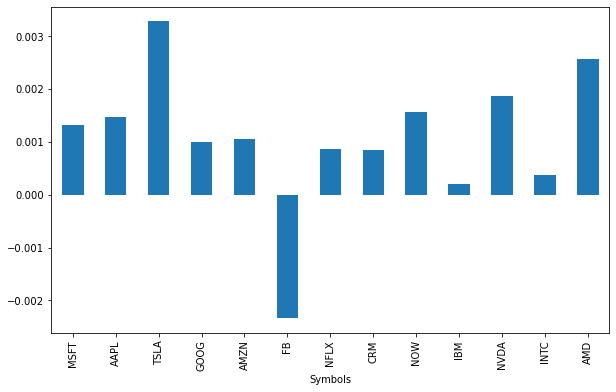

In [17]:
eod.pct_change().mean().plot(kind='bar', figsize=(10, 6));

In [18]:
returns = np.log(eod / eod.shift(1))
returns.head().round(3)

Symbols,MSFT,AAPL,TSLA,GOOG,AMZN,FB,NFLX,CRM,NOW,IBM,NVDA,INTC,AMD
Date,,,,,,,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,0.005,-0.000,-0.010,0.016,0.013,NaN,0.020,0.008,0.009,0.027,0.064,-0.035,0.051
2018-01-04,0.009,0.005,-0.008,0.004,0.004,NaN,0.003,0.013,0.007,0.020,0.005,-0.019,0.048
2018-01-05,0.012,0.011,0.006,0.014,0.016,NaN,0.021,0.013,0.009,0.005,0.008,0.007,-0.020
2018-01-08,0.001,-0.004,0.061,0.004,0.014,NaN,0.010,0.007,0.002,0.006,0.030,0.000,0.033


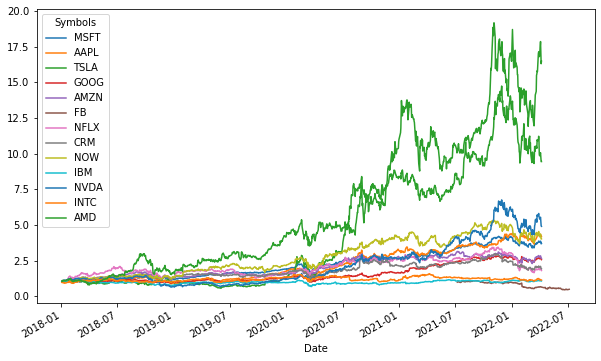

In [19]:
returns.cumsum().apply(np.exp).plot(figsize=(10, 6));

## Resampling
When dealing with data that occurs over a long period of time, resampling can help shape the data for readability. Instead of looking at the ticks for every single day, we can *downsample* the data and only show the tick at every week or at every month.

In [20]:
eod.resample('1w', label='right').last().head()

Symbols,MSFT,AAPL,TSLA,GOOG,AMZN,FB,NFLX,CRM,NOW,IBM,NVDA,INTC,AMD
Date,,,,,,,,,,,,,
2018-01-07,83.460663,41.728760,63.316002,1102.229980,61.457001,NaN,209.990005,108.099998,135.009995,125.251205,53.336170,39.875034,11.88
2018-01-14,84.795052,42.227123,67.244003,1122.260010,65.260002,NaN,221.229996,110.239998,138.190002,125.752258,55.213081,38.538151,12.02
2018-01-21,85.173592,42.553795,70.003998,1137.510010,64.728996,NaN,220.460007,111.930000,142.270004,125.158730,56.978577,39.946346,12.59
2018-01-28,89.015862,40.896564,68.570000,1175.839966,70.102501,NaN,274.600006,113.699997,149.740005,128.989716,60.252041,44.634377,12.95
2018-02-04,86.858139,38.271236,68.750000,1111.900024,71.497498,NaN,267.429993,110.779999,149.759995,122.584145,57.822941,41.131721,12.45


In [21]:
eod.resample('1m', label='right').last().head()

Symbols,MSFT,AAPL,TSLA,GOOG,AMZN,FB,NFLX,CRM,NOW,IBM,NVDA,INTC,AMD
Date,,,,,,,,,,,,,
2018-01-31,89.914932,39.923687,70.862000,1169.939941,72.544502,NaN,270.299988,113.910004,148.869995,126.183907,60.863651,42.905331,13.74
2018-02-28,89.158287,42.645889,68.612000,1104.729980,75.622498,NaN,291.380005,116.250000,161.009995,121.300171,59.959953,44.228325,12.11
2018-03-31,86.781219,40.170265,53.226002,1031.790039,72.366997,NaN,295.350006,116.300003,165.449997,119.432007,57.380688,46.731800,10.05
2018-04-30,88.920593,39.566914,58.779999,1017.330017,78.306503,NaN,312.459991,120.989998,166.139999,112.838821,55.723110,46.319050,10.88
2018-05-31,94.386276,44.913349,56.945999,1084.989990,81.481003,NaN,351.600006,129.330002,177.610001,111.218666,62.523357,49.817287,13.73


<AxesSubplot:xlabel='Date'>

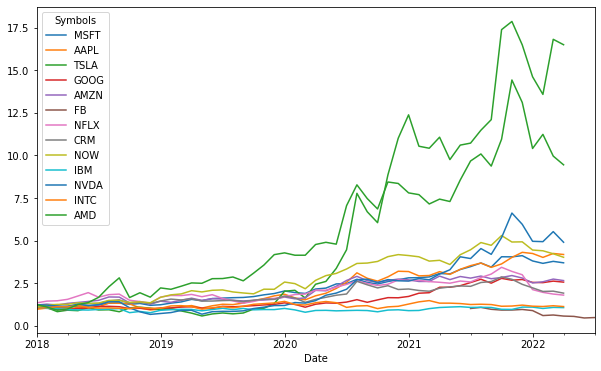

In [22]:
returns.cumsum().apply(np.exp).resample('1m', label='right').last().plot(figsize=(10,6))

## Rolling Statistics
Looking at time series data allows us to analyze statics that occur over time. Apparent trends can be found within the stock that are referred to as *financial indicators* or *financial studies*. I'll demonstrate on a single stock

In [23]:
sym = 'AMD'
data = pd.DataFrame(eod[sym]).dropna()
data.tail()

,AMD
Date,
2022-04-01,108.190002
2022-04-04,110.529999
2022-04-05,106.820000
2022-04-06,103.669998
2022-04-07,103.720001


In [24]:
window = 20
data['min'] = data[sym].rolling(window=window).min()
data['max'] = data[sym].rolling(window=window).max()
data['mean'] = data[sym].rolling(window=window).mean()
data['std'] = data[sym].rolling(window=window).std()
data['median'] = data[sym].rolling(window=window).median()
data['ewma'] = data[sym].rolling(window=window).median()
data.dropna().head()

,AMD,min,max,mean,std,median,ewma
Date,,,,,,,
2018-01-30,12.87,10.98,13.32,12.2875,0.549669,12.230,12.230
2018-01-31,13.74,11.55,13.74,12.4255,0.550593,12.345,12.345
2018-02-01,13.25,11.82,13.74,12.5105,0.539429,12.440,12.440
2018-02-02,12.45,11.82,13.74,12.5270,0.531850,12.460,12.460
2018-02-05,11.57,11.57,13.74,12.5115,0.555681,12.460,12.460


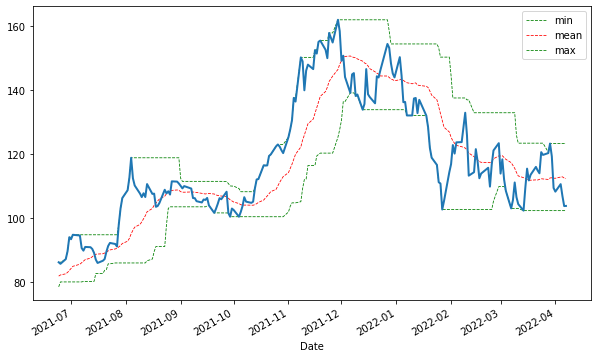

In [25]:
ax = data[['min', 'mean', 'max']].iloc[-200:].plot(
    figsize=(10,6), style=['g--', 'r--', 'g--'], lw=0.8
)

data[sym].iloc[-200:].plot(ax=ax, lw=2.0);

## A Technical Analysis Example
* Rolling statistics are an important tool in the *technical analysis* of stocks
* Fundamental analysis used to consist of financial reports and strategic positions of a company (high propensity for bias)
* Decades old strategy is *simple moving averages* (SMAs)
     - Trader should go long on a stock when the shorter-term SMA is above the longer-term SMA
     - Go short when the longer-term SMA is above the shorter-term SMA

In [26]:
data['SMA1'] = data[sym].rolling(window=42).mean()
data['SMA2'] = data[sym].rolling(window=252).mean()
data[[sym, 'SMA1', 'SMA2']].tail()

,AMD,SMA1,SMA2
Date,,,
2022-04-01,108.190002,115.621667,109.459127
2022-04-04,110.529999,115.330476,109.574563
2022-04-05,106.820000,115.014762,109.672262
2022-04-06,103.669998,114.540238,109.752897
2022-04-07,103.720001,114.065238,109.836071


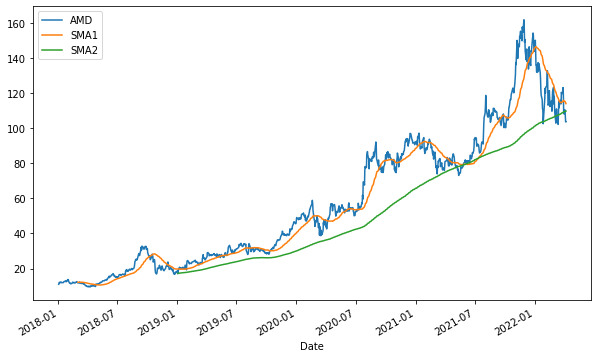

In [27]:
data[[sym, 'SMA1', 'SMA2']].plot(figsize=(10,6));

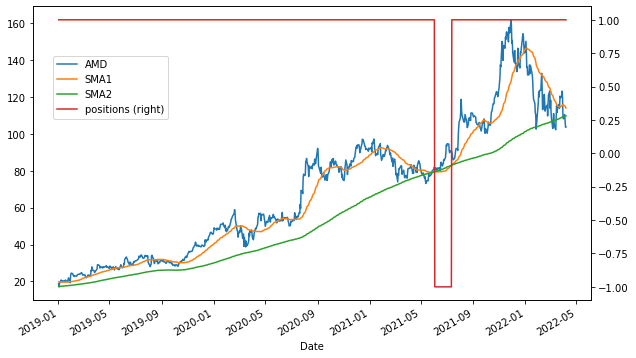

In [28]:
data.dropna(inplace=True)
data['positions'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)
ax = data[[sym, 'SMA1', 'SMA2', 'positions']].plot(figsize=(10,6), secondary_y='positions')
ax.get_legend().set_bbox_to_anchor((0.25, 0.85));

## Correlation Analysis
As a reminder, when comparing variables, a correlation is a statistical indicator of the relationship between variables. Causation means that changes in one variable brings about changes in the other; there is a cause-and-effect relationship between variables. As a real-world example, consider the S&P 500 and the VIX volatility index. We can gather statistical evidence that these two stocks are (highly) negatively correlated.

In [29]:
tick_data = wb.DataReader(indexes[1:], 'yahoo', start_date, end_date)
eod = tick_data['Adj Close']
for ric, name in zip(eod.columns, index_instruments[1:]):
    print('{:8s} | {}'.format(ric, name))

^GSPC    | S&P 500 Index
^VIX     | VIX Volatility Index


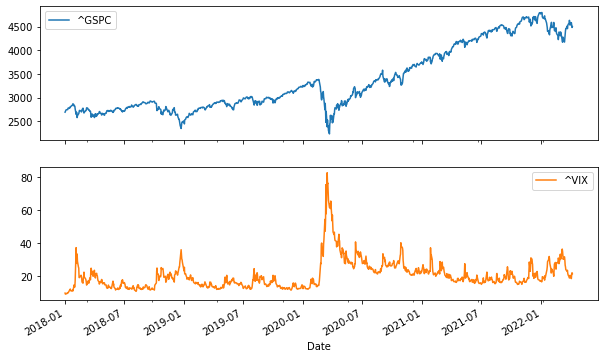

In [30]:
eod.plot(subplots=True, figsize=(10,6));

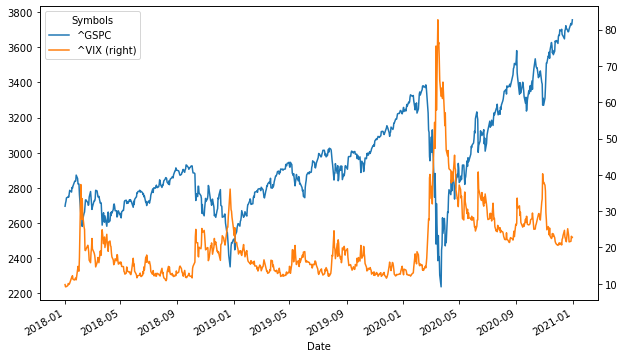

In [31]:
eod.loc[:'2020-12-31'].plot(secondary_y='^VIX', figsize=(10,6));

## Logarithmic Returns
Statistical analysis typically relies on returns instead of absolute changes or even absolute values. There is high variability in log returns over time, as we look at the two indexes =, "volatility clusters" can easily be spotted. In general, periods of high volatility are accompanied by the same phenomena in the volatility index.

In [32]:
returns = np.log(eod/eod.shift(1))
returns.dropna(inplace=True)
returns.head()

Symbols,^GSPC,^VIX
Date,,
2018-01-03,0.006378,-0.065563
2018-01-04,0.004021,0.007621
2018-01-05,0.007009,0.000000
2018-01-08,0.001661,0.032020
2018-01-09,0.001302,0.057158


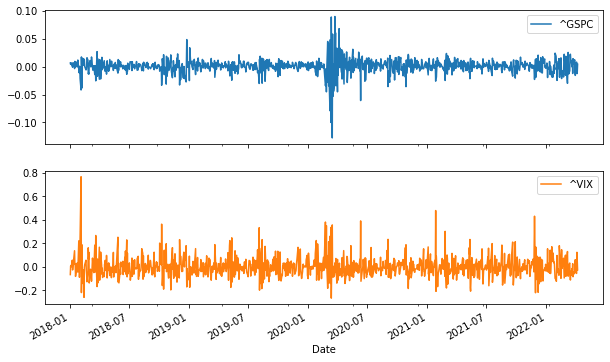

In [33]:
returns.plot(subplots=True, figsize=(10,6));

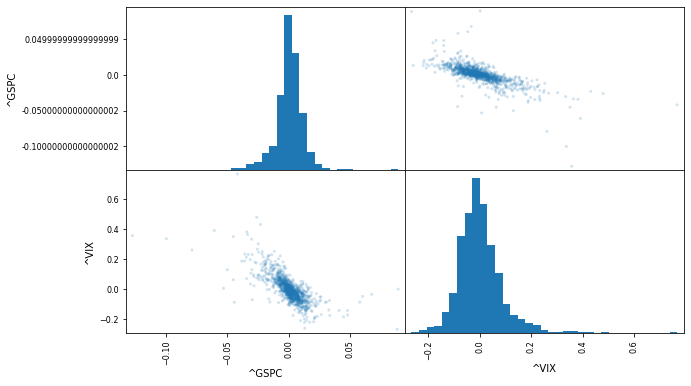

In [34]:
pd.plotting.scatter_matrix(returns,
                          alpha=0.2,
                          diagonal='hist',
                          hist_kwds={'bins': 35},
                          figsize=(10,6));

## OLS Regression
Ordinary least-squares regression analysis is convenient to implement. The next scatter plot will show the log returns and a linear regression line. The negative slope provides further evidence that the correlation between the two stocks is negative.

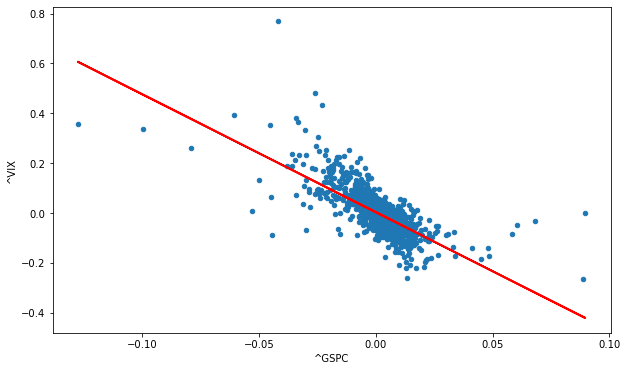

In [35]:
reg = np.polyfit(returns['^GSPC'], returns['^VIX'], deg=1)
ax = returns.plot(kind='scatter', x='^GSPC', y='^VIX', figsize=(10,6))
ax.plot(returns['^GSPC'], np.polyval(reg, returns['^GSPC']), 'r', lw=2);

## Correlation
We can consider correlation measures directly as well. Take into account a static data set and a rolling one to show the correlation over a fixed window. We can use these measures to support a hypothesis on correlation.

In [36]:
returns.corr()

Symbols,^GSPC,^VIX
Symbols,,
^GSPC,1.000000,-0.720974
^VIX,-0.720974,1.000000


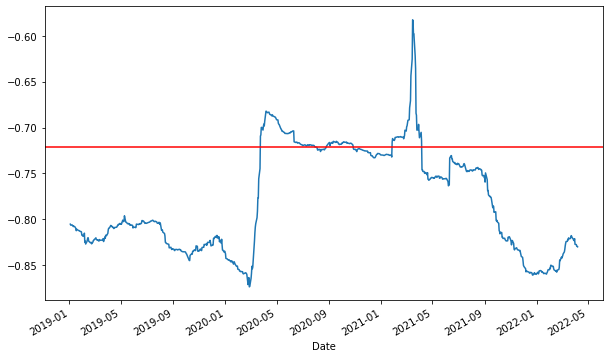

In [37]:
ax = returns['^GSPC'].rolling(window=252).corr(returns['^VIX']).plot(figsize=(10,6))
ax.axhline(returns.corr().iloc[0,1], c='r');

## High Frequency Data
When working with tick data, it is often necessary to resample a graph or frame. The amount of data that is produced is vast, and as shows with the pandas datareader API into yahoo, massive amounts of data can quickly be pulled into a data frame and visualized. [Nasdaq-Data-Link](https://blog.quantinsti.com/nasdaq-data-link/#:~:text=Step%201%20%2D%20Go%20to%20the,using%20Quandl%20API%20in%20Python.)

In [38]:
tick = wb.DataReader('IBM', 'yahoo', start_date, end_date)

In [39]:
tick['Bid'] = tick['High']
tick['Ask'] = tick['Low']
tick.drop(['High', 'Low', 'Open', 'Close', 'Volume', 'Adj Close'], axis=1, inplace=True)

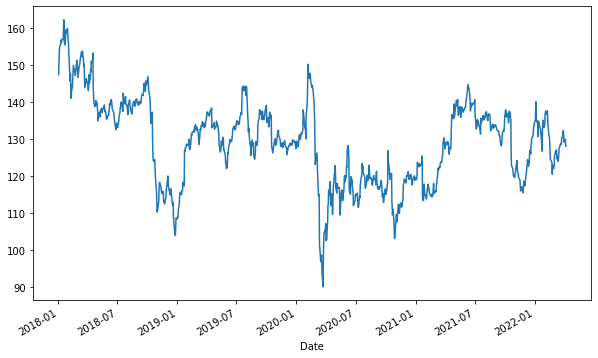

In [40]:
tick['Mid'] = tick.mean(axis=1)
tick['Mid'].plot(figsize=(10,6));

In [41]:
tick_resam = tick.resample(rule='1m', label='right').last()
tick_resam.dropna(inplace=True)
tick_resam.head()

,Bid,Ask,Mid
Date,,,
2018-01-31,157.734222,155.602295,156.668259
2018-02-28,151.185471,148.948380,150.066925
2018-03-31,147.122375,144.435944,145.779160
2018-04-30,140.898666,138.585083,139.741875
2018-05-31,136.529633,134.847031,135.688332


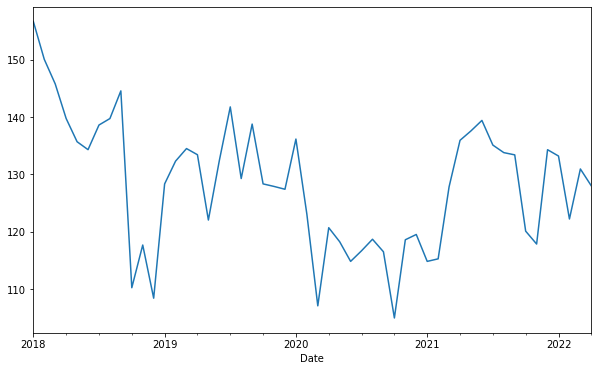

In [42]:
tick_resam['Mid'].plot(figsize=(10,6));

## Conclusions
Financial time-series data can be accessed quickly using python's pandas library. Once we have the data shaped into a frame, visualizing and analyzing the data for trends allows us to make inferences from that data. We can quickly blend datasets and perform a variety of tasks autonomously with the jupyter notebook environment. When considering a 'data-driven' strategy, we must look at the implementation of tools, alongside analytic processes.

While this notebook will serve as a good technical grounding in analyzing time-series data, later chapters will cover trading strategies and detail how we might incorporate specific features of the data to inform a prediction / decision. Extended reading on financial time-series data could be incredibly helpful when analyzing the market. Here is a [quora post](https://www.quora.com/What-are-some-fantastic-books-on-time-series-analysis) that provides more references. 